# PyTorch Workflow
Let's explore a an example PyTorch end-toend workflow.

Resources:
* Ground truth notebook - 

In [ ]:
what_were_covering = {
    1: "data (prepare and load)",
    2: "build model",
    3: "fitting the model to data(training )",
    4: "making prediction and evaluating a model (inference)",
    5: "saving and loading a model",
    6: "putting it all together",
}
what_were_covering

In [ ]:
import torch
from torch import nn # nn contains all of PyTorch's buidling block for neural networks
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Check PyTorch version
torch.__version__

## 1. Data (preparing and loading)

Data can be almost anything... in machine learning.
* Excel spreadsheet
* Images of any kind
* Videos (YouTube have a lot of data )
* Audio
* DNA
* TExt
Machine learning is a game of two part:
1. Get data into a numerical representaion.
2. Build a model to learn patterns in that numerical representation.
To showcase this, let's create some *know* data using the linear regression formula
We'll use a linear regression formula to make a straight line with know **paramater**


In [ ]:
# Create *know* paramater
weight = 0.7
bias = 0.3

### Formula of Linear Regression
# y = a + bx (a => bias) and (b = weight or gradient) 

########## Create ##########
start = 0
end = 1
step = 0.02
X = torch.arange(start,end,step).unsqueeze(dim=1)
y = weight*X+bias
plt.scatter(X,y)
plt.xlabel("Input")
plt.title("Making a Ml Model using pytorch")
plt.ylabel("Output")
plt.show()
print(y)

### Splitting data into training and test sets (one of the most important concepts in machine learning in general )
Let's create a training and test set with our data.

In [ ]:
# Create a train/test split
train_split = int(0.8*len(X))
X_train,Y_train = X[:train_split],y[:train_split]
X_test,Y_test = X[train_split:],y[train_split:]
len(X_train),len(Y_train),len(X_test),len(Y_test)

How might we better visualize our data?
This is where are data explorer's motto comes in!
"visualize,visualize,visualize" 

In [ ]:
def plot_prediction(prediction=None):
    """PLots training data,test data and compaer predictions."""
    plt.figure(figsize=(10,7))
    plt.scatter(X_train,Y_train,c='b',s=5,label="Training Data") 
    plt.scatter(X_test,Y_test, c="g",s=5,label="Testing Data")
    if(prediction is not None):
        # Plot the prediction
        plt.scatter(X_test, prediction, c="r", s=5, label="Prediction Data")
    # Show the legend 
    plt.legend(prop={"size":14})

In [ ]:
plot_prediction()

## 2. Build Model
Our first PyTorch model!
This is very exciting... let's do it!
What our model does:
* Start with random values (weight & bias)
* Look at training data and adjust the random value to better represent (or get closer to) the ideal values ( the weight & bias values we used to create the data)
How does it do so? 
Through two main algorithms:
1. Gradient descent
2. Backpropogation

In [ ]:
# Create linear regression model class
class LinearRegressionModel(
    nn.Module
):  # <- almost everthing in PyTorch inherits from nn.Module
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(
            torch.rand(1, requires_grad=True, dtype=torch.float)
        ) 

        self.bias = nn.Parameter(torch.rand(1, requires_grad=True, dtype=torch.float))

    # Forward method to define the computation in the model
    def forward(self, X: torch.Tensor) -> torch.Tensor:  # <- "x" is the input data

        return self.weights * X + self.bias

### Checking the content of our PyTorch model 
Now we've created a model, let's see what's inside...
So we can check our model paramater  or what's inside our model using  `.parameters()`

In [ ]:
# Create a random seed 
RANDOM_SEED = torch.manual_seed(42)

# Create an instance of the model ( this is the subclass of nn.Module)

model_0 = LinearRegressionModel()

# check out the paramater
print(list(model_0.parameters()))

In [ ]:
# List named parameters
model_0.state_dict()

### Making prediction using `torch.inference_mode()`
To check our model's predictive power, let's see how well it predicted `y_test` based on  `X_test`
When we pass data through our model, it's going to run it through the `forward()` method.

In [ ]:
# Make predictions with model 
with torch.inference_mode():
    y_preds = model_0(X_test)  

# You can also do something similar with torch.no_grad(), however, inferrence_mode() is preferred
y_preds

In [ ]:
Y_test

In [ ]:
plot_prediction(prediction=y_preds)

## 3. Train model 
The whole idea of training is for a model to move from some *unknown* paramaters (these may be random) to some *known*
paramaters or in other words from a poor representation of the data to a better representation of the data.
One way to measure how poor or how wrong your models predictions are is to use a loss function.
* Note: Loss function may also be called cost function or criterion in different areas. For our case, we're going to refer to it as a loss function.

Things we need to train:


* **Loss function:** A function to measure how wrong your model's predictions are to the ideal outputs, lower is better.
* **Optimizer:**  Takes into account the loss of a model  and adjusts the model's parameters (e.g. weight & bias) to improve the loss function.
And specifically for PyTorch, we need:
* A training loop
* Testing loop


In [ ]:
list(model_0.parameters())

In [ ]:
# Check out our model's parameters (a parameter is a value that the model sets itself)
model_0.state_dict()



In [ ]:
# Setup a lost function (MAE Mean Absolute Error)
       
loss_fn = nn.L1Loss()


# Setups an optimizer (SGD Stochastic Gradient Descent)
optimizer = torch.optim.SGD(params=model_0.parameters(),# parmas
                            lr=0.01, # lr = learning rate = possible the most hyperparameter you can set
                            momentum=0.9)
 

### 4. Building a training loop (and a testing Loop) in **PyTorch**
A couple of things we need in a training loop:

0. Looop through the data
1. forward pass (this involve data moving through our models's `forward()` functions) to make prediction on data- also called forward propagation
2. Calculate the loss (compare forward pass predictions to ground truth labels)
3. Optimizer zero grad
4. Loss backward - move backward through the network to calculate the gradients each of the paramater of our model with respect to the loss (**Backpropagation**)
5. Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss (**Gradient Descent**)

In [ ]:
# An epoch is one loop through the data...
epochs = 100

epoch_count = []
loss_values = []
test_loss_values = []
### Training
# 0. Loop through the data
for epoch in range(epochs):

    # Set the model to training mode
    model_0.train()  # train mode in PyTorch set all parameters that require gradient to require gradients

    # 1. Forward pass
    y_pred = model_0(X_train)

    # 2. Calculate the loss
    loss = loss_fn(Y_train, y_pred)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Perform backpropagation on the loss with respect to the parameter of the model
    loss.backward()

    # 5. Step the optimizer (perform gradient descent)

    optimizer.step()  # by default how the optimizer changes will acculumate through the loop so... we have to zero them in step 3 for the next iteration of the loop

    # ---- Testing  ----#

    model_0.eval()  # turns off gradient tracking
    with torch.inference_mode():
        test_pred = model_0(X_test)
        test_loss = loss_fn(test_pred, Y_test)
    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss)

        test_loss_values.append(test_loss)

In [ ]:
plt.plot(epoch_count,np.array(torch.tensor(loss_values).cpu().numpy()),label="Train Loss")
plt.plot(epoch_count,test_loss_values,label="Test loss")
plt.title("Loss curve")
plt.legend()

In [ ]:
model_0.state_dict()

In [ ]:
model_0.state_dict()

In [ ]:
with torch.inference_mode():
    y_pred_new = model_0(X_test)

In [ ]:
plot_prediction(prediction=y_preds)

In [ ]:

plot_prediction(prediction=y_pred_new)

# Saving a model in PyTorch
There are three main methods you should about for saving and loading in PyTorch.

1. `torch.save()` - allow you save PyTorch obeject in Python pickles format
2. `torch.load()` - allow you load a saved PyTorch object
3. `torch.nn.load_state_dict()` - this allows to load a model's saved state dictionary


In [ ]:
# Saving our PyTorch model
from pathlib import Path

# 1. Create models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)
# 2. Create model save path
MODEL_NAME = "01_pytorch_workflow_model_0.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME
# 3. Save the model Stat Dict
print(f"Saving model to:{MODEL_SAVE_PATH}")
torch.save(model_0.state_dict(), MODEL_SAVE_PATH)

## Loading a PyTorch model
Sine we saved our model's `state_dict()` rather than entire model,we'll create a new instance of our model class and load saved `state_dicta()`
into that

In [ ]:
model_0.state_dict

In [ ]:
# To load in a saved state_dict we have to instantiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()
# Load the saved state_dict of model_0 (this will update the new instance with updated parameters)
loaded_model_0.load_state_dict(torch.load(MODEL_SAVE_PATH))

In [ ]:
loaded_model_0.state_dict()

In [ ]:
model_0.state_dict()

In [ ]:
# make some prediction
loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test)
loaded_model_preds
    

In [ ]:
loaded_model_preds=y_pred_new

In [ ]:
model_0.eval()
with torch.inference_mode():
    y_preds = model_0(X_test)

In [ ]:
loaded_model_preds == y_preds

## 6. Putting it all together
Let's g back through the steps above and see it all in one place


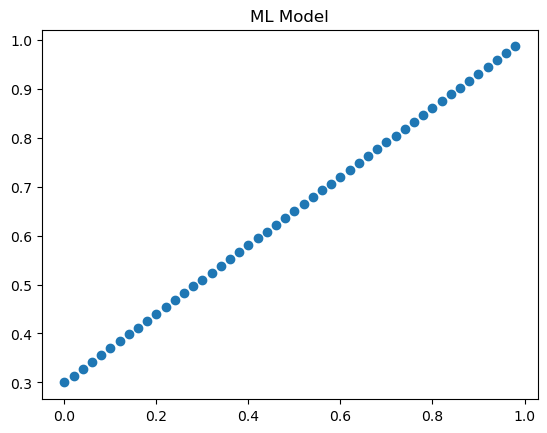

OrderedDict({'linear_layer.weight': tensor([[0.7645]]), 'linear_layer.bias': tensor([0.8300])})


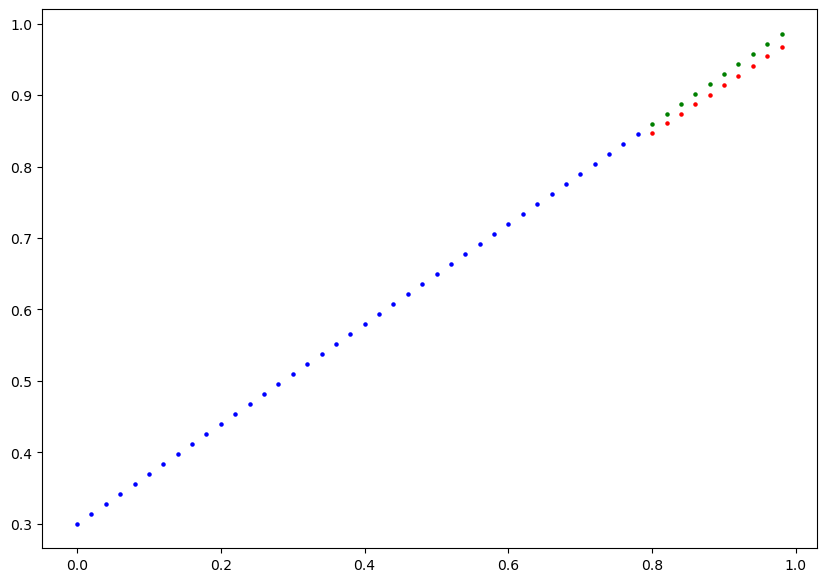

Saving the model: models\02_pytorch_workflow.pth


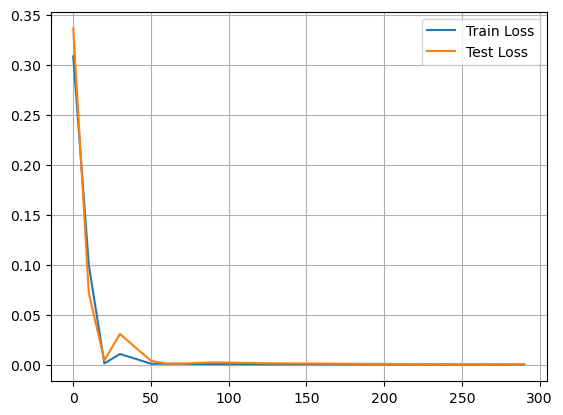

In [12]:
# Import PyTorch and matplotlib
import matplotlib.pyplot as plt
import torch
from torch import nn

torch.manual_seed(42)

slope = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step, dtype=torch.float32)

y = slope * X + bias

plt.title("ML Model")
plt.scatter(X, y)
plt.show()

train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split].unsqueeze(1), y[:train_split].unsqueeze(1)
X_test, y_test = X[train_split:].unsqueeze(1), y[train_split:].unsqueeze(1)


def plot_prediction(y_predictions=None):
    plt.figure(figsize=(10, 7))
    plt.scatter(X_train, y_train, s=5, c="b")
    plt.scatter(X_test, y_test, s=5, c="g")
    if y_predictions is not None:
        plt.scatter(X_test, y_predictions, s=5, c="r")
    plt.show()


class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        # self.weight = nn.Parameter(torch.rand(1))
        # self.bias = nn.Parameter(torch.rand(1))
        # <-Using Linear Layers for creating the model parameter ->
        self.linear_layer = nn.Linear(in_features=1,out_features=1)

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(X)


model = LinearRegressionModel()

print(model.state_dict())
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=.9)

epochs = 300
epoch_count = []
test_loss_values = []
loss_values = []

for epoch in range(epochs):
    model.train()
    y_pred = model(X_train)
    loss = loss_fn(y_pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_pred = model(X_test)
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 10 == 0:
        epoch_count.append(epoch)
        test_loss_values.append(test_loss.item())
        loss_values.append(loss.item())

with torch.inference_mode():
    plot_prediction(y_predictions=test_pred)

# Save the model
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "02_pytorch_workflow.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(model.state_dict(), MODEL_SAVE_PATH)
print(f"Saving the model: {MODEL_SAVE_PATH}")


# Load the model
plt.plot(epoch_count, loss_values, label="Train Loss")
plt.plot(epoch_count, test_loss_values, label="Test Loss")
plt.legend()
plt.grid()
plt.show()

In [7]:
X_train.dtype,y_train.dtype

(torch.float32, torch.float32)

6.1 Data